## Lojistik Regresyon Temel Kavramları

Lojistik regresyon, sınıflandırma problemlerinde kullanılan temel bir makine öğrenmesi algoritmasıdır. Amacı, bağımlı (hedef/çıktı) ile bağımsız (girdi) değişkenler arasındaki ilişkiyi modelleyerek, bir gözlemin belirli bir sınıfa ait olma olasılığını tahmin etmektir.

---

### Lojistik Regresyonun Amacı

Lojistik regresyon, bir olayın olma olasılığını tahmin etmek için kullanılır. Örneğin; bir hastanın diyabet olup olmadığını (evet/hayır), bir e-postanın spam olup olmadığını (spam/değil) tahmin edebilirsiniz.

---

### Temel Formül

Lojistik regresyonun temelinde, doğrusal bir denklemin (regresyon) çıktılarını 0 ile 1 arasına sıkıştırmak için sigmoid fonksiyonu kullanılır.

**Sigmoid (Lojistik) Fonksiyonu:**

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$

Burada:
- $\hat{y}$ : Tahmin edilen olasılık (çıktı, 0 ile 1 arasında bir değer alır)
- $z$ : Doğrusal regresyon sonucudur

**Doğrusal Regresyon Kısmı:**

$$
z = b + w_1 x_1 + w_2 x_2 + w_3 x_3 + \ldots + w_p x_p
$$

Burada:
- $b$ : Bias (sabit terim)
- $w_1, w_2, ..., w_p$ : Girdi değişkenlerinin katsayıları (ağırlıklar)
- $x_1, x_2, ..., x_p$ : Girdi değişkenlerinin kendileri

### Nasıl Çalışır?

1. Doğrusal kombinasyon: Önce girdi değişkenleri ile katsayılar çarpılıp bias terimi eklenir.
2. Sigmoid fonksiyonu: Elde edilen bu değer sigmoid fonksiyonundan geçirilir ve çıktı 0-1 arasında bir olasılık olur.
3. Sınıflandırma kararı: Eğer bu olasılık belirlenen bir eşik değerinden (genellikle 0.5) büyükse, model pozitif sınıfı (ör. 1) tahmin eder; küçükse negatif sınıfı (ör. 0) tahmin eder.

---

### Log Loss (Lojistik Kayıp Fonksiyonu)

Lojistik regresyonda modelin başarısını değerlendirmek için Log Loss olarak adlandırılan bir kayıp fonksiyonu kullanılır. Log Loss, gerçek değerler ile tahmin edilen olasılıkların ne kadar uyumsuz olduğunu ölçer. Log Loss değeri ne kadar düşükse, model o kadar iyi demektir.

**Log Loss matematiksel olarak şöyle tanımlanır:**

$$
Log \, Loss = -\frac{1}{m} \left( \sum_{i=1}^m \left[ y_i \cdot \log(p(\hat{y}_i)) + (1 - y_i) \cdot \log(1 - p(\hat{y}_i)) \right] \right)
$$

Burada:
- $m$ : Toplam gözlem sayısı
- $y_i$ : Gerçek sınıf etiketi (0 veya 1)
- $p(\hat{y}_i)$ : $i$’inci gözlem için modelin tahmin ettiği olasılık

---

### Özetle

- Lojistik regresyon, doğrusal bir modeli 0-1 arası olasılığa dönüştürerek sınıflandırma problemi çözer.
- Tahmin: Bir gözlemin belirtilen sınıfa ait olma olasılığıdır.
- Kullanım alanları: Hastalık tahmini, spam tespiti, kredi riski analizi vb.

## 🍎 Adım Adım: Verilen Değerlerle Olasılık Hesabı

**Soru:**  
Verilen bias (b) ve weight'lere (w) göre aşağıdaki gözlem birimi için 1 sınıfına ait olma olasılığını hesaplayınız.

---

### 📋 Verilenler

- $b = 5$
- $w_1 = 1$
- $w_2 = -4$
- $w_3 = 3$
- $x_1 = 2$
- $x_2 = 3$
- $x_3 = 0$

---

### 🧮 Formül

- Doğrusal kombinasyon:  
  $z = b + w_1 x_1 + w_2 x_2 + w_3 x_3$
- Sigmoid (olasılık):  
  $\hat{y} = \frac{1}{1 + e^{-z}}$

---

### 🟢 **Adım 1: z değerini hesapla**

$z = 5 + (1 \times 2) + (-4 \times 3) + (3 \times 0)$

$z = 5 + 2 - 12 + 0$

$z = -5$

---

### 🟢 **Adım 2: Sigmoid ile olasılığı hesapla**

$\hat{y} = \frac{1}{1 + e^{-z}}$

$\hat{y} = \frac{1}{1 + e^{-(-5)}} = \frac{1}{1 + e^{5}}$

$e^{5} \approx 148.41$

$\hat{y} = \frac{1}{1 + 148.41} \approx \frac{1}{149.41} \approx 0.0067$

---

### 🎯 **Sonuç**

- Bu gözlem biriminin 1 sınıfına ait olma olasılığı: **0.0067** (yani %0.67)

### 💡 Lojistik Regresyonda Gradient Descent Adımları

#### 1️⃣. **Maliyet Fonksiyonu (Cost Function) Nedir?**
Lojistik regresyonda, modelimizin tahminleri ile gerçek değerler arasındaki farkı en aza indirmek isteriz. Bunu ölçmek için bir maliyet fonksiyonu tanımlarız.

$$
J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \text{Cost}(h_\theta(x^{(i)}),\ y^{(i)})
$$

Burada $m$ toplam gözlem sayısı, $h_\theta(x^{(i)})$ ise modelin $i$. gözlem için tahmin ettiği olasılıktır.

#### 2️⃣. **Lojistik Regresyonda Cost Fonksiyonunun Detayı**
Lojistik regresyonda cost fonksiyonu şöyle yazılır:

$$
J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]
$$

Burada:
- $y^{(i)}$ : Gerçek değer (etiket)
- $h_\theta(x^{(i)})$ : Tahmin edilen olasılık

#### 3️⃣. **Gradient Descent (Gradyan İnişi) ile Minimuma İlerleme**
Amaç, parametreleri ($\theta$) güncelleyerek cost fonksiyonunu minimuma indirmektir. Bu güncelleme aşağıdaki formül ile yapılır:

$$
\theta_j := \theta_j - \alpha \cdot \frac{\partial}{\partial \theta_j} J(\theta)
$$

- $\alpha$ : Öğrenme oranı (learning rate)
- $\frac{\partial}{\partial \theta_j} J(\theta)$ : Cost fonksiyonunun $\theta$'ya göre türevi (gradyan)

#### 4️⃣. **Adım Adım Gradient Descent Süreci**
1. Parametreler ($\theta$) başlangıçta genellikle 0 veya küçük rastgele değerler olarak atanır.
2. Maliyet fonksiyonu ve gradyanlar hesaplanır.
3. Gradient descent formülüyle parametreler güncellenir.
4. Hata istenen seviyeye gelene kadar adımlar tekrarlanır.

#### 🔄 **Özetle:**
- Maliyet fonksiyonunu kur,
- Gradyan inişiyle parametreleri güncelle,
- Bu işlemleri model istenen başarıya ulaşana kadar uygula!

### 🔢 Confusion Matrix (Karışıklık Matrisi) Nedir?

Bir sınıflandırma modelinin başarısını ölçmek için kullanılan bir tablodur. Modelin tahminlerinin doğruluğunu sınıf bazında gösterir. 

Aşağıda, 2 sınıflı (binary) bir problem için confusion matrix'in yapısı gösterilmektedir:

|                  | **Tahmin Edilen Sınıf**: 1 | **Tahmin Edilen Sınıf**: 0 |
|------------------|:-------------------------:|:-------------------------:|
| **Gerçek Sınıf**: 1 | True Positive (TP)        | False Negative (FN)        |
| **Gerçek Sınıf**: 0 | False Positive (FP)       | True Negative (TN)         |

#### Açıklamalar:
- **True Positive (TP):** Model, örneği doğru şekilde 1 (pozitif) olarak tahmin etti.
- **False Negative (FN):** Model, aslında 1 olan örneği yanlışlıkla 0 olarak tahmin etti.
- **False Positive (FP):** Model, aslında 0 olan örneği yanlışlıkla 1 olarak tahmin etti.
- **True Negative (TN):** Model, örneği doğru şekilde 0 (negatif) olarak tahmin etti.

Bu matris, modelin hem doğru, hem de yanlış tahminlerini detaylı şekilde incelememizi sağlar.

### Accuracy Nedir?

Accuracy, bir sınıflandırma modelinin doğru tahminlerinin, toplam tahmin sayısına oranıdır. Matematiksel olarak:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Burada:
- $TP$: True Positive (doğru pozitif tahmin)
- $TN$: True Negative (doğru negatif tahmin)
- $FP$: False Positive (yanlış pozitif tahmin)
- $FN$: False Negative (yanlış negatif tahmin)

Accuracy, tüm sınıflar arasında modelin genel doğruluğunu ölçer. Ancak, dengesiz veri setlerinde yanıltıcı olabilir. Bu nedenle, bazen precision (kesinlik), recall (duyarlılık) gibi ek metriklere de ihtiyaç duyulabilir.

### 🎯 Precision ve Recall Nedir?

**Precision (Kesinlik):**  
Precision, modelin pozitif olarak tahminlediği örneklerden kaç tanesinin gerçekten pozitif olduğunu gösterir.  
Yani, "Model pozitif dediğinde ne kadar isabetli?" sorusunun cevabıdır.  
Matematiksel ifadesi:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Burada:  
$TP$: True Positive (doğru pozitif tahmin)  
$FP$: False Positive (yanlış pozitif tahmin)  

**Recall (Duyarlılık, Hassasiyet):**  
Recall, gerçekten pozitif olan örneklerden kaç tanesinin model tarafından doğru şekilde pozitif olarak tahmin edildiğini gösterir.  
Yani, "Gerçek pozitifleri bulma yeteneğim ne kadar iyi?" sorusuna cevap verir.  
Matematiksel ifadesi:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Burada:  
$TP$: True Positive (doğru pozitif tahmin)  
$FN$: False Negative (yanlış negatif tahmin)  

🎓 Kıyaslama:  
**Precision** yüksekse, modelin "pozitif" tahminleri genellikle doğrudur.  
**Recall** yüksekse, model neredeyse tüm gerçek pozitifleri tespit eder.  
Çoğu durumda, modelin kullanıldığı senaryoya göre precision’a veya recall’a daha fazla önem verilir.  

Örneğin:  
Kanser teşhisinde **recall** daha önemli olabilir (hiçbir hastayı atlamak istemeyiz).  
E-posta spam tespitinde ise **precision** daha önemli olabilir (gerçek bir e-postayı yanlışlıkla spam olarak işaretlemek istemeyiz).

### 🎯 F1 Skoru Nedir?

**F1 Skoru**, precision (kesinlik) ve recall (duyarlılık) metriklerinin harmonik ortalamasıdır. Modelinizin hem gerçek pozitifleri bulma başarısını (recall), hem de pozitif tahminlerinin doğruluğunu (precision) birlikte dikkate alır. Özellikle dengesiz veri setlerinde, F1 skoru daha anlamlı ve dengeli bir performans ölçütü sunar.

Matematiksel olarak:

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

**Özetle:**
- F1 skoru 0 ile 1 arasında bir değere sahiptir (1 en iyi, 0 en kötü).
- Precision ile recall arasında bir denge kurmak istiyorsak F1 skoru önem arz eder.
- Modelin hem yanlış pozitifler hem de kaçırılmış gerçek pozitiflerle ilgili başarısı önemliyse F1 skoru tercih edilmelidir.

**Örnek Senaryolar:**
- Kanser teşhisinde, hastaları kaçırmamak önemli olduğu için recall önemli ancak yanlış pozitifler azalmak isteniyorsa F1 skoru iyi bir ölçü olur.
- Sınıf dengesizliğinin olduğu veri setlerinde F1 skoru, accuracy'den daha gerçekçi bilgi sunar.

**Kısaca:**  
F1 skoru yüksek olan bir model, hem doğru pozitifleri yüksek oranda buluyordur hem de yaptığı pozitif tahminler büyük oranda doğrudur.

### Sınıflandırma Eşiği (Classification Threshold) Nedir?

Makine öğrenmesinde, özellikle lojistik regresyonda, modelimiz her bir gözlem için bir olasılık (örneğin, diyabet hastası olma ihtimali) üretir. Ancak, sonuç olarak bir sınıf tahmini (0 veya 1 gibi) yapmak için bu olasılığın hangi noktada "pozitif" sayılacağına karar vermemiz gerekir. İşte bu kritik nokta *sınıflandırma eşiği* (classification threshold) olarak adlandırılır.

Varsayılan olarak, genellikle eşik değeri 0.5 alınır. Yani, modelin tahmini olasılığı 0.5’in üzerindeyse gözlem *pozitif* (1), altında ise *negatif* (0) olarak sınıflandırılır. Ancak bu değer her problemde en iyi sonucu vermez; modelin kullanım amacına ve veri setindeki sınıf dengesine göre optimum eşik değeri değişebilir.

**Eşik Değeri Nasıl Seçilir?**
- Eşik değeri düşürülürse (örneğin 0.3), model daha fazla gözlemi pozitif olarak tahmin eder. Bu, *recall*’ı arttırırken *precision*’ı azaltabilir.
- Eşik değeri yükseltilirse (örneğin 0.7), model daha az gözlemi pozitif olarak tahmin eder. Bu durumda *precision* artar, *recall* ise azalabilir.
- Hangi eşik değerinin seçileceği, problemde nelere öncelik verildiğine göre belirlenir. Örneğin, hastalık tespitinde önemli olan hatalı negatifleri (hasta olup sağlıklı görünenleri) azaltmaksa, recall’u yükseltecek bir düşük eşik tercih edilir.

**En iyi eşik nasıl bulunur?**  
Çoğu zaman, ROC eğrisi ve AUC, precision-recall eğrileri gibi metrikler, farklı eşiklerde model performansını değerlendirmeye yardımcı olur. Bu analizler doğrultusunda uygulamaya ve ihtiyaçlara uygun en iyi eşik değeri belirlenir.

**Kısacası:**  
Sınıflandırma eşiği, modelin verdiği olasılıkları gerçek sınıf kararına dönüştürmede kritik bir parametredir. Optimum değeri seçmek, model başarısı ve uygulama amacına uygun güvenilir sonuçlar elde etmek için çok önemlidir.

### ROC Eğrisi (Receiver Operating Characteristic Curve) Nedir?

**ROC eğrisi**, sınıflandırma modellerinin başarısını ölçmek ve farklı eşiklerde nasıl çalıştığını değerlendirmek için kullanılan önemli bir araçtır. Özellikle dengesiz veri setlerinde modelin gerçek performansını görebilmek için sıklıkla başvurulur.

ROC eğrisi, yatay eksende **Yanlış Pozitif Oranı (False Positive Rate - FPR)**, dikey eksende ise **Doğru Pozitif Oranı (True Positive Rate - TPR)** yani **recall** değerlerini gösterir. Modelin olasılık tahminlerine ait eşik değeri değiştirildikçe, FPR ve TPR değerleri değişir ve bunların her bir kombinasyonu birer nokta olarak ROC eğrisinin üzerinde yer alır.

- **True Positive Rate (Recall / Duyarlılık):** Gerçek pozitiflerin, doğru olarak pozitif bulunma oranı.  
  $$
  TPR = \frac{TP}{TP + FN}
  $$

- **False Positive Rate (Yanlış Pozitif Oranı):** Gerçek negatiflerin, yanlışlıkla pozitif olarak tahmin edilme oranı.  
  $$
  FPR = \frac{FP}{FP + TN}
  $$

### ROC Eğrisinin Yorumu:
- ROC eğrisi ne kadar sol üst köşeye yakınsa, model o kadar başarılıdır.
- Rastgele tahmin yapan bir modelin ROC eğrisi, köşeden köşeye (45°) çapraz bir doğru olur.
- Modelin ROC eğrisinin altında kalan alanına **AUC (Area Under Curve)** denir ve 0.5 ile 1 arasında değer alır. AUC 1’e yaklaştıkça model daha başarılıdır.

### Ne zaman ROC/AUC kullanılır?
- **Sınıf dengesizliği** olan veri setlerinde, accuracy yanıltıcı olduğunda modelin gerçek performansını görmek için kullanılır.
- Farklı eşiklerdeki model davranışını analiz etmek istediğimizde tercih edilir.

---

**Kısaca:**  
ROC eğrisi ve AUC skoru, sınıflandırma modellerinin güçlü ve zayıf yönlerini detaylıca gözlemleyebilmemizi sağlar ve en uygun eşik değerini seçmede yardımcı olur.

### Log Loss (Lojistik Kayıp, Binary Cross-Entropy) Nedir?

**Log Loss**, sınıflandırma modellerinde tahmin edilen olasılıkların doğruluğunu nicel olarak ölçen bir kayıp (loss) fonksiyonudur. Özellikle lojistik regresyon ve benzeri olasılık temelli modellerde yaygın olarak kullanılır.

Log loss ile modelin sınıflandırma performansı yalnızca doğru/yanlış üzerinden değil, tahmin edilen olasılıkların gerçek değerlere ne kadar yakın olduğuna göre değerlendirilir.

#### Formül (Binary Sınıflandırma için):

$$
\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} \Big[ y_i \cdot \log(\hat{p}_i) + (1-y_i) \cdot \log(1 - \hat{p}_i) \Big]
$$

- $N$: Toplam gözlem sayısı
- $y_i$: $i$'inci gözlemin gerçek sınıfı (0 veya 1)
- $\hat{p}_i$: $i$'inci gözlemin pozitif sınıfa (1) ait olma tahmin olasılığı

#### Yorum

- Log loss değeri sıfıra yaklaştıkça modelin hem doğru sınıfı bulmada hem de olasılıkları gerçekçi vermede başarılı olduğu anlaşılır.
- Log loss yüksekse, model yanlış ve aşırı emin tahminler yapıyor demektir.

## Problem: Predicting Diabetes with Logistic Regression

Bu çalışmada, bireylerin belirli özelliklerine bakılarak diyabet hastası olup olmadıklarının tahmin edilmesi amaçlanmaktadır. Kullanılan veri seti, ABD Ulusal Diyabet-Sindirim-Böbrek Hastalıkları Enstitüleri tarafından tutulmakta olup, Arizona Eyaleti Phoenix şehrinde yaşayan 21 yaş üzerindeki Pima Indian kadınlarına aittir. Veri seti 768 gözlem ve 8 sayısal bağımsız değişkenden oluşmaktadır. Hedef değişken ise "Outcome" olup; 1 değeri diyabet hastası, 0 değeri ise hasta olmayan bireyi göstermektedir.

### Değişkenler

- **Pregnancies:** Hamilelik sayısı
- **Glucose:** Glikoz seviyesi
- **BloodPressure:** Kan basıncı
- **SkinThickness:** Cilt kalınlığı
- **Insulin:** İnsülin seviyesi
- **BMI:** Beden kitle indeksi
- **DiabetesPedigreeFunction:** Soy geçmişine göre diyabet riski
- **Age:** Yaş (yıl)
- **Outcome:** Diyabet durumu (1: hasta, 0: değil)

### Adımlar

1. **Exploratory Data Analysis (Keşifsel Veri Analizi)**
2. **Data Preprocessing (Veri Ön İşleme)**
3. **Model & Prediction (Model ve Tahmin)**
4. **Model Evaluation (Model Değerlendirme)**
5. **Model Validation: Holdout (Geçerlilik: Holdout Yöntemi)**
6. **Model Validation: 10-Fold Cross Validation (10 Katlı Doğrulama)**
7. **Prediction for a New Observation (Yeni Gözlem için Tahmin)**

In [2]:
import matplotlib.pyplot as plt  # Grafik çizimleri için kullanılır
import numpy as np               # Sayısal işlemler ve çok boyutlu diziler için kullanılır
import pandas as pd              # Veri analizi ve veri yapıları için kullanılır
import seaborn as sns            # Gelişmiş görselleştirme (grafik) araçları sağlar

from sklearn.preprocessing import RobustScaler      # Aykırı değerlere karşı dayanıklı bir ölçekleme yöntemi
from sklearn.linear_model import LogisticRegression # Lojistik regresyon modeli oluşturmak için
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report # Değerlendirme metrikleri
from sklearn.model_selection import train_test_split, cross_validate   # Veri bölme ve çapraz doğrulama işlemleri

# Aykırı değer eşiklerini hesaplayan fonksiyon
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)                          # Belirtilen sütunun %5'lik (q1) çeyreklik değeri alınır
    quartile3 = dataframe[col_name].quantile(q3)                          # Belirtilen sütunun %95'lik (q3) çeyreklik değeri alınır
    interquantile_range = quartile3 - quartile1                           # Çeyreklik aralığı hesaplanır
    up_limit = quartile3 + 1.5 * interquantile_range                      # Üst sınır: 95. yüzdelik + 1.5 * çeyreklik aralığı
    low_limit = quartile1 - 1.5 * interquantile_range                     # Alt sınır: 5. yüzdelik - 1.5 * çeyreklik aralığı
    return low_limit, up_limit                                            # Hesaplanan alt ve üst sınır döndürülür

# Sütunda aykırı değer olup olmadığını kontrol eden fonksiyon
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)         # Sütunun aykırı değer sınırları hesaplanır
    # Eğer sütunda sınırların dışında herhangi bir değer varsa True döndürülür, yoksa False
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

# Aykırı değerleri eşik değerlerle değiştiren fonksiyon
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)      # Aykırı değer sınırları hesaplanır
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit  # Alt sınırın altındaki değerler alt sınıra eşitlenir
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit   # Üst sınırın üzerindeki değerler üst sınıra eşitlenir

# pandas çıktı ayarları: tablo sütunlarının tamamını ve sayıların ondalık hassasiyetini ayarlamak için
pd.set_option('display.max_columns', None)                      # Tüm sütunları göster
pd.set_option('display.float_format', lambda x: '%.3f' % x)     # Ondalık gösterimi üç basamakla sınırla
pd.set_option('display.width', 500)                             # Çıktı genişliğini artır


In [5]:
# Exploratory Data Analysis
df = pd.read_csv("datasets/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
# Target'ın Analizi

df["Outcome"].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

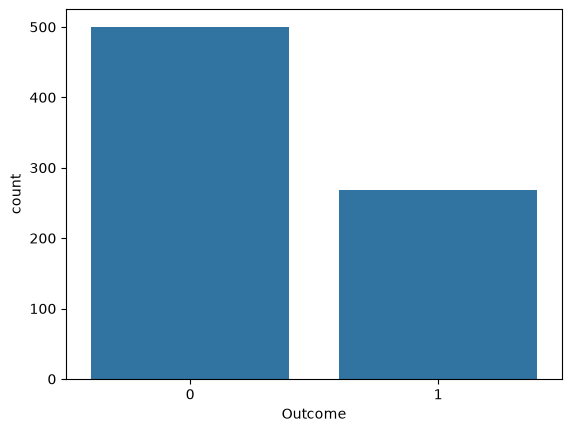

In [8]:
sns.countplot(x="Outcome", data=df)
plt.show()

In [ ]:
100 * df["Outcome"].value_counts() / len(df)

Outcome
0   65.104
1   34.896
Name: count, dtype: float64

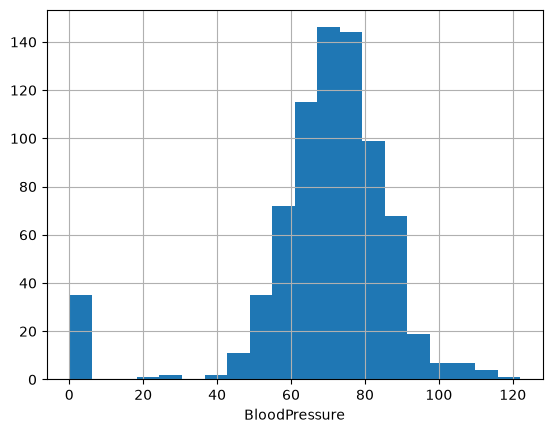

In [10]:
# Feature'ların Analizi
df["BloodPressure"].hist(bins=20)
plt.xlabel("BloodPressure")
plt.show()

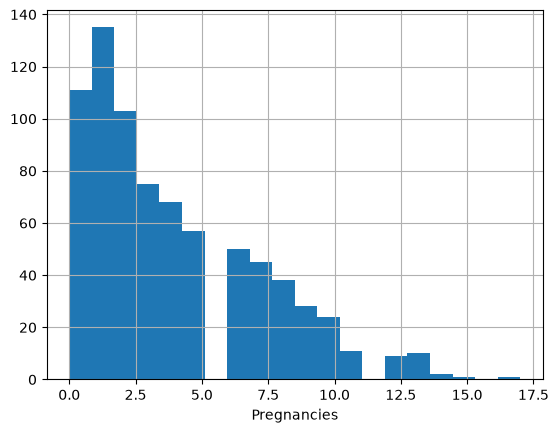

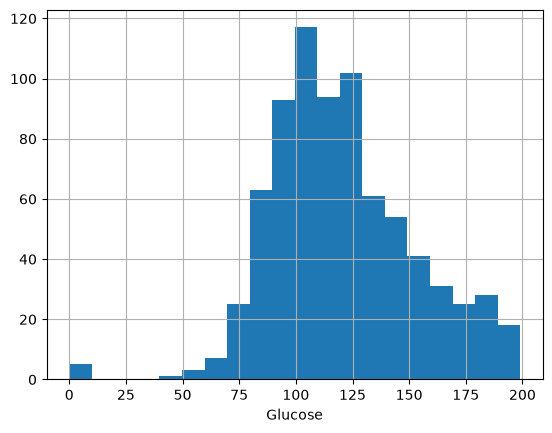

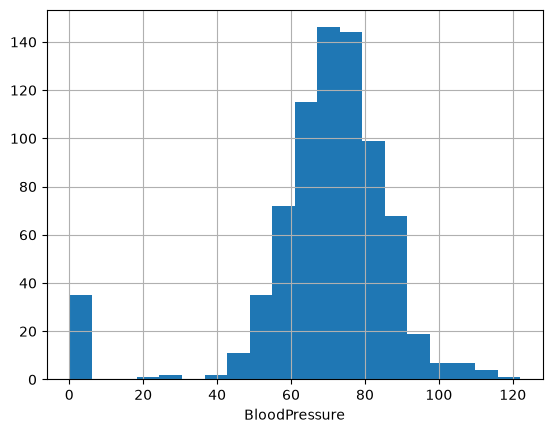

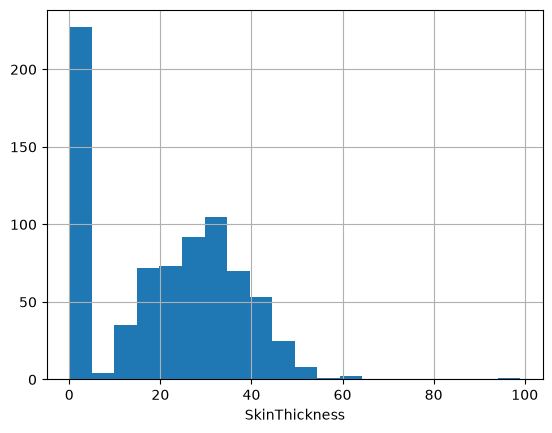

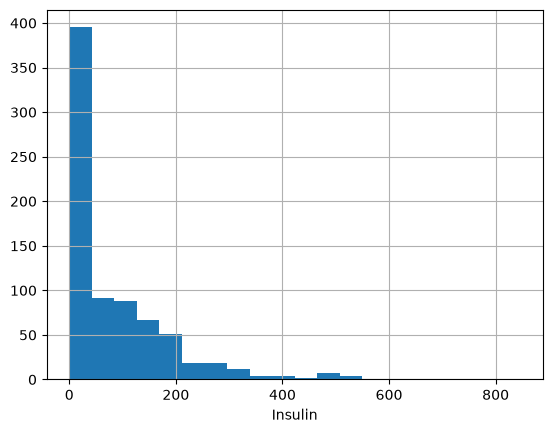

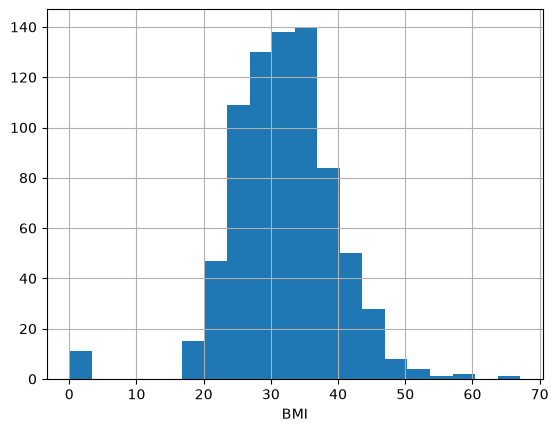

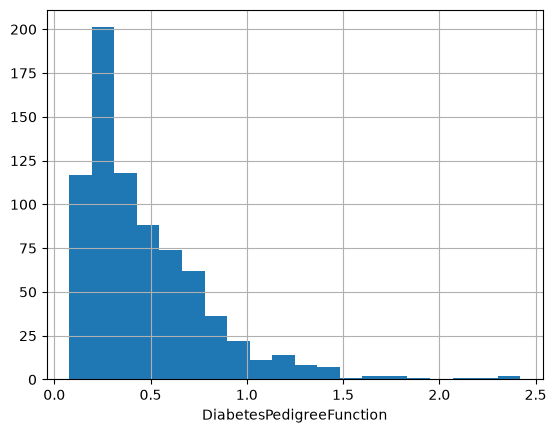

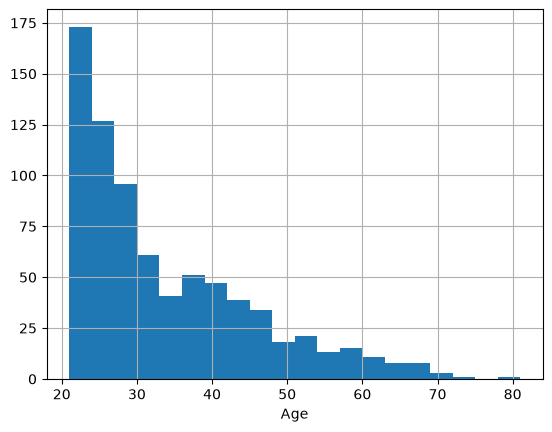

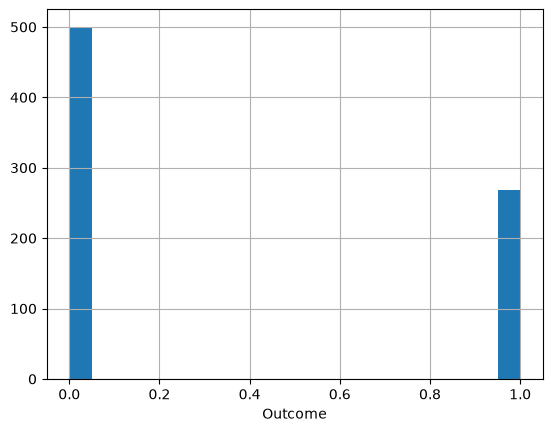

In [11]:
def plot_numerical_col(dataframe, numerical_col):
    dataframe[numerical_col].hist(bins=20)
    plt.xlabel(numerical_col)
    plt.show(block=True)


for col in df.columns:
    plot_numerical_col(df, col)

In [12]:
cols = [col for col in df.columns if "Outcome" not in col]
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [13]:
# Target vs Features
df.groupby("Outcome").agg({"Pregnancies": "mean"})

def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

for col in cols:
    target_summary_with_num(df, "Outcome", col)


         Pregnancies
Outcome             
0              3.298
1              4.866


         Glucose
Outcome         
0        109.980
1        141.257


         BloodPressure
Outcome               
0               68.184
1               70.825


         SkinThickness
Outcome               
0               19.664
1               22.164


         Insulin
Outcome         
0         68.792
1        100.336


           BMI
Outcome       
0       30.304
1       35.143


         DiabetesPedigreeFunction
Outcome                          
0                           0.430
1                           0.550


           Age
Outcome       
0       31.190
1       37.067




In [14]:
# Data Preprocessing (Veri Ön İşleme)
df.isnull().sum() # Boş değerleri kontrol et

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [19]:
for col in cols:
    print(col, check_outlier(df, col))

    # Outlier replacement only for float columns to avoid LossySetitemError
if df[col].dtype in ['float64', 'float32']:
    replace_with_thresholds(df, col)


Pregnancies False
Glucose False
BloodPressure False
SkinThickness False
Insulin True
BMI False
DiabetesPedigreeFunction False
Age False


In [20]:
for col in cols:
    df[col] = RobustScaler().fit_transform(df[[col]])

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.600,0.752,0.000,0.375,-0.240,0.172,0.665,1.235,1
1,-0.400,-0.776,-0.333,0.188,-0.240,-0.581,-0.056,0.118,0
2,1.000,1.600,-0.444,-0.719,-0.240,-0.935,0.783,0.176,1
3,-0.400,-0.679,-0.333,0.000,0.499,-0.419,-0.537,-0.471,0
4,-0.600,0.485,-1.778,0.375,1.081,1.194,5.008,0.235,1


In [21]:
# Model ve Tahminleme (Model & Prediction) Adımları Açıklaması

# 1. Bağımlı Değişken (hedef değişken) ve Bağımsız Değişkenlerin Ayrılması
# 'Outcome' sütunu tahmin etmek istediğimiz etikettir (diyabet hastalığı var mı yok mu?).
y = df["Outcome"]  # Bağımlı değişken (etiket)
X = df.drop(["Outcome"], axis=1)  # Bağımsız değişkenler (özellikler)

# 2. Lojistik Regresyon Modelinin Kurulması ve Eğitilmesi
# Burada, sklearn kütüphanesinden LogisticRegression sınıfını kullanarak modelimizi oluşturup verimize fit ediyoruz.
log_model = LogisticRegression().fit(X, y)

# 3. Modelin Öğrendiği Kesişim (intercept_) ve Katsayılar (coef_)
# Modelin bulduğu sabit ve özellik katsayılarına erişebiliriz.
log_model.intercept_  # Kesişim (bias)
log_model.coef_       # Katsayılar

# 4. Model ile Tahmin Yapmak
# Eğitim verisi üzerinden tahmin üretimi (genel olarak test seti ile de denenmelidir)
y_pred = log_model.predict(X)

# 5. İlk 10 tahmini ve gerçek değeri inceleyelim
y_pred[0:10]  # Modelin ilk 10 gözlem için ürettiği tahminler
y[0:10]       # Gerçek etiketler


0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: Outcome, dtype: int64

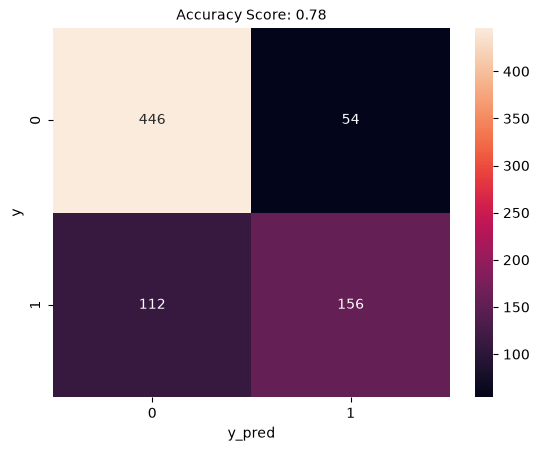

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       500
           1       0.74      0.58      0.65       268

    accuracy                           0.78       768
   macro avg       0.77      0.74      0.75       768
weighted avg       0.78      0.78      0.78       768

ROC AUC Score: 0.83937


In [22]:
# Model Değerlendirmesi (Model Evaluation)
# Modelin başarı durumu, doğruluk ve hata oranları ile incelenir. 
# Aşağıda önce öngörülen ve gerçek değerlerin bir karmaşıklık matrisi (confusion matrix) ile karşılaştırılması,
# ardından temel sınıflandırma metriklerinin raporlanması (accuracy, precision, recall, f1-score) yapılır:

def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

# Karmaşıklık matrisiyle görselleştirme
plot_confusion_matrix(y, y_pred)

# Sınıflandırma raporunun yazdırılması
print(classification_report(y, y_pred))

# Bazı temel değerlere örnek:
# Accuracy: 0.78
# Precision: 0.74
# Recall: 0.58
# F1-score: 0.65

# ROC AUC Skoru Hesaplama
y_prob = log_model.predict_proba(X)[:, 1]
roc_auc = roc_auc_score(y, y_prob)
print("ROC AUC Score:", round(roc_auc, 5))


              precision    recall  f1-score   support

           0       0.77      0.92      0.84        97
           1       0.79      0.53      0.63        57

    accuracy                           0.77       154
   macro avg       0.78      0.72      0.73       154
weighted avg       0.78      0.77      0.76       154



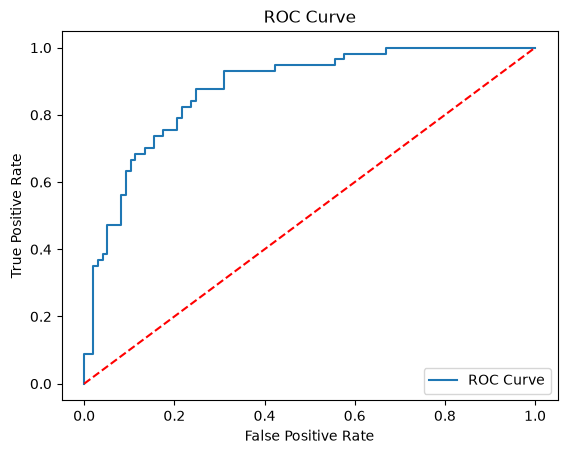

Test Seti ROC AUC Skoru: 0.87557


In [25]:
# Model Doğrulama: Holdout Yöntemi

# Holdout yöntemi ile veri setini eğitim ve test olarak ayırıp gerçekçi model performansı incelemesi yapılır.

# 1. Eğitim ve Test Setlerinin Oluşturulması
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=17)

# 2. Modeli Eğitim Seti Üzerinde Eğitme
log_model = LogisticRegression().fit(X_train, y_train)

# 3. Test Setinde Tahmin Üretme
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# 4. Test Seti Sonuçlarının Değerlendirilmesi
print(classification_report(y_test, y_pred))

# ROC Eğrisi Çizimi ve AUC Hesabı (plot_roc_curve tanımlı değil hatası nedeniyle elle çizim)
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

auc_score = roc_auc_score(y_test, y_prob)
print("Test Seti ROC AUC Skoru:", round(auc_score, 5))

In [26]:
# Model Doğrulama: 10-Katlı (K-Fold) Çapraz Doğrulama

# Bu yöntemle, modelin farklı veri altkümesi kombinasyonlarında değerlendirilerek daha genel ve sağlam bir doğruluk ölçümü elde edilir.
# cross_validate fonksiyonu ile hem doğruluk (accuracy), hem de precision, recall, f1 ve roc_auc skorları hesaplanacaktır.

from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    log_model,              # tahminci nesnesi
    X,                      # özellikler (bağımsız değişkenler)
    y,                      # hedef değişken (bağımlı değişken)
    cv=5,                   # 5-katlı çapraz doğrulama (isteğe göre 10 da yapılabilir)
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

print("CV Accuracy: ", round(cv_results['test_accuracy'].mean(), 4))
print("CV Precision:", round(cv_results['test_precision'].mean(), 4))
print("CV Recall:   ", round(cv_results['test_recall'].mean(), 4))
print("CV F1:       ", round(cv_results['test_f1'].mean(), 4))
print("CV ROC AUC:  ", round(cv_results['test_roc_auc'].mean(), 4))

# Yorumlar:
# - cross_validate sayesinde farklı train-test bölünmelerinde modelin başarısına dair istatistikler elde edilir.
# - Her skorun ortalaması genel model başarısını gösterir.

CV Accuracy:  0.7709
CV Precision: 0.7155
CV Recall:    0.5747
CV F1:        0.6358
CV ROC AUC:   0.8328


In [27]:
# 5. Yeni Bir Gözlem İçin Tahmin
# Model eğitilirken kullanılan özellik isimlerini getiriyoruz:
print("Modelde Kullanılan Özellikler:", list(X.columns))

# Rastgele bir kullanıcı/gözlem seçiyoruz (tekrar üretilebilirlik için random_state belirtilmiştir)
random_user = X.sample(1, random_state=45)
print("Tahmin Yapılacak Yeni Gözlem Satırı:\n", random_user)

# Seçilen gözlem için modelden sınıf tahmini alıyoruz
user_prediction = log_model.predict(random_user)
print("Yeni Gözlem İçin Tahmin Edilen Sınıf:", user_prediction[0])

Modelde Kullanılan Özellikler: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Tahmin Yapılacak Yeni Gözlem Satırı:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction   Age
195        0.400    0.994          0.667          0.562    1.411 0.796                     0.059 0.000
Yeni Gözlem İçin Tahmin Edilen Sınıf: 1
